<a href="https://colab.research.google.com/github/fernandopr11/LiveTrainingModel/blob/main/LiveTrainingModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalacion de dependencias
!pip install torch torchvision facenet-pytorch opencv-python pillow numpy pandas matplotlib seaborn scikit-learn tqdm albumentations mtcnn coremltools onnx onnx-coreml tqdm albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from facenet_pytorch import InceptionResnetV1
import coremltools as ct
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import json
from datetime import datetime
from tqdm import tqdm
from google.colab import drive


In [4]:
# Montar Google Drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo"
DIRS = {
    'models': f"{BASE_DIR}/models",
    'results': f"{BASE_DIR}/results",
    'exports': f"{BASE_DIR}/exports_ios",
    'data_raw': f"{BASE_DIR}/data/raw",
    'data_processed': f"{BASE_DIR}/data/processed"
}

# Crear directorios
for dir_name, dir_path in DIRS.items():
    os.makedirs(dir_path, exist_ok=True)
    print(f"📁 {dir_name}: {dir_path}")

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Dispositivo: {device}")

# Crear archivo de log del experimento
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE = f"{DIRS['results']}/experimento_{timestamp}.log"

def log_message(message):
    """Función para logging"""
    with open(LOG_FILE, 'a') as f:
        f.write(f"{datetime.now()}: {message}\n")
    print(message)

log_message("🚀 Iniciando experimento de entrenamiento facial en vivo")

Mounted at /content/drive
📁 models: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/models
📁 results: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/results
📁 exports: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/exports_ios
📁 data_raw: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/data/raw
📁 data_processed: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/data/processed

🖥️ Dispositivo: cpu
🚀 Iniciando experimento de entrenamiento facial en vivo


In [6]:
# PASO 2 MODELO BASE PARA ENTRENAMIENTO EN VIVO
class LiveFaceModel(nn.Module):
    """Modelo optimizado para entrenamiento en vivo"""

    def __init__(self):
        super(LiveFaceModel, self).__init__()

        # Cargar InceptionResNetV1 preentrenado
        self.backbone = InceptionResnetV1(
            pretrained='vggface2',
            classify=False
        )

        # Congelar capas base (para velocidad)
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Solo las últimas capas entrenan (RÁPIDO)
        for param in self.backbone.last_linear.parameters():
            param.requires_grad = True
        for param in self.backbone.last_bn.parameters():
            param.requires_grad = True

        # Clasificador para usuario/no-usuario
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Binario
        )

    def forward(self, x):
        # Extraer embedding
        embedding = self.backbone(x)
        # Clasificar
        output = self.classifier(embedding)
        return output, embedding

model = LiveFaceModel().to(device)

  0%|          | 0.00/107M [00:00<?, ?B/s]

In [7]:
# Mostrar parámetros entrenables
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
log_message(f"📊 Parámetros entrenables: {trainable:,} de {total:,} ({100*trainable/total:.1f}%)")

log_message("✅ Modelo creado y arquitectura guardada")

📊 Parámetros entrenables: 984,450 de 27,976,249 (3.5%)
✅ Modelo creado y arquitectura guardada


In [12]:
# =============================================================================
# PASO 3: CONFIGURACIÓN DE MTCNN Y PROCESAMIENTO DE ROSTROS
# =============================================================================

print("\n🔍 PASO 3: CONFIGURACIÓN DE MTCNN Y PROCESAMIENTO")
print("=" * 60)

# PASO 3.1: Configurar detector de rostros MTCNN
print("🔍 Configurando detector de rostros MTCNN...")
mtcnn = MTCNN(
    image_size=160,              # Tamaño de salida del rostro (compatible con InceptionResnetV1)
    margin=20,                   # Margen alrededor del rostro
    min_face_size=80,            # Tamaño mínimo de rostro a detectar
    thresholds=[0.6, 0.7, 0.7],  # Umbrales de detección [P, R, O]
    factor=0.709,                # Factor de escala para pirámide de imágenes
    post_process=True,           # Normalización automática
    device=device
)
print("✅ Detector MTCNN configurado")


🔍 PASO 3: CONFIGURACIÓN DE MTCNN Y PROCESAMIENTO
🔍 Configurando detector de rostros MTCNN...
✅ Detector MTCNN configurado


📂 Buscando imágenes en: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/data/raw
✅ Encontradas 15 imágenes

🖼️ Ejemplo de detección con: Copia de Copia de 25989FEF-FE68-47FD-B0E1-58ADB1688911.JPG


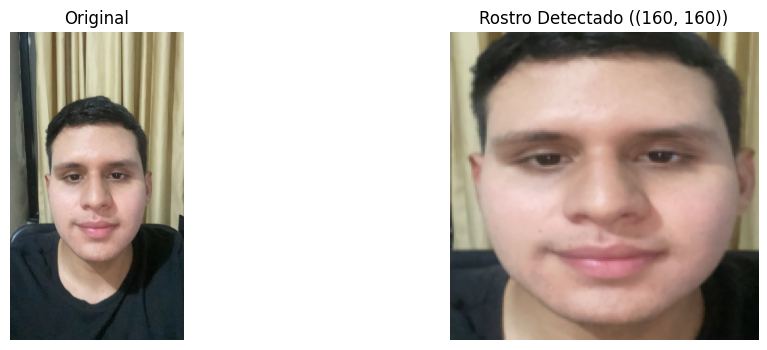


🔄 Procesando 15 imágenes con MTCNN...


Detectando rostros:   7%|▋         | 1/15 [00:00<00:08,  1.56it/s]

   👤 Copia de Copia de 25989FEF-FE68-47FD-B0E1-58ADB1688911.JPG → face_Copia de Copia de 25989FEF-FE68-47FD-B0E1-58ADB1688911_001.jpg


Detectando rostros:  13%|█▎        | 2/15 [00:01<00:08,  1.51it/s]

   👤 Copia de Copia de DBA52F5D-7566-4041-B50E-DDE75D02F217.JPG → face_Copia de Copia de DBA52F5D-7566-4041-B50E-DDE75D02F217_002.jpg


...

   👤 Copia de Copia de 8A1DD490-86DF-4C79-BB4D-7CA936846DD1.JPG → face_Copia de Copia de 8A1DD490-86DF-4C79-BB4D-7CA936846DD1_013.jpg


Detectando rostros:  93%|█████████▎| 14/15 [00:06<00:00,  2.33it/s]

   👤 Copia de Copia de 445B6AB0-AD40-4527-B6AC-1711D399306A.JPG → face_Copia de Copia de 445B6AB0-AD40-4527-B6AC-1711D399306A_014.jpg


Detectando rostros: 100%|██████████| 15/15 [00:07<00:00,  2.13it/s]

   👤 Copia de Copia de 7B15C604-76F3-46CA-A785-46E4BB52D4A7.JPG → face_Copia de Copia de 7B15C604-76F3-46CA-A785-46E4BB52D4A7_015.jpg
✅ Rostros extraídos: 15/15


In [13]:
# PASO 3.2: Función para detectar y extraer rostros
def detectar_y_extraer_rostro(imagen_path, mostrar=False):
    """
    Detecta y extrae el rostro principal de una imagen usando MTCNN
    """
    try:
        # Cargar imagen
        img = Image.open(imagen_path).convert('RGB')

        # Detectar rostro con MTCNN
        img_cropped = mtcnn(img)

        if img_cropped is not None:
            # Convertir tensor a PIL Image
            if isinstance(img_cropped, torch.Tensor):
                # Desnormalizar de [-1,1] a [0,255]
                img_cropped = (img_cropped + 1) / 2 * 255
                img_cropped = img_cropped.permute(1, 2, 0).cpu().numpy().astype(np.uint8)
                img_cropped = Image.fromarray(img_cropped)

            if mostrar:
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 2, 1)
                plt.imshow(img)
                plt.title("Original")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(img_cropped)
                plt.title(f"Rostro Detectado ({img_cropped.size})")
                plt.axis('off')
                plt.show()

            return img_cropped
        else:
            print(f"⚠️  No se detectó rostro en {imagen_path.name}")
            return None

    except Exception as e:
        print(f"❌ Error procesando {imagen_path.name}: {str(e)}")
        return None

def crear_dataset_simulado():
    """Crea un dataset simulado para demostración"""

    processed_dir = Path(DIRS['data_processed'])

    print("🎭 Generando dataset simulado con rostros...")

    # Crear 10 imágenes base simuladas con rostros más realistas
    for i in range(10):
        # Crear imagen base de 160x160 (ya el tamaño que necesita MTCNN)
        image = np.ones((160, 160, 3), dtype=np.uint8) * 220  # Fondo claro

        # Añadir características faciales más definidas
        # Cara ovalada
        image[20:140, 40:120] = [210, 180, 150]  # Tono de piel

        # Ojos más realistas
        # Ojo izquierdo
        image[50:65, 50:70] = [255, 255, 255]    # Blanco del ojo
        image[55:62, 57:64] = [100, 50, 30]      # Iris marrón
        image[58:61, 59:62] = [0, 0, 0]          # Pupila

        # Ojo derecho
        image[50:65, 90:110] = [255, 255, 255]   # Blanco del ojo
        image[55:62, 96:103] = [100, 50, 30]     # Iris marrón
        image[58:61, 98:101] = [0, 0, 0]         # Pupila

        # Cejas
        image[45:50, 48:72] = [80, 60, 40]       # Ceja izquierda
        image[45:50, 88:112] = [80, 60, 40]      # Ceja derecha

        # Nariz más detallada
        image[75:95, 75:85] = [190, 160, 130]
        image[90:95, 77:83] = [170, 140, 110]    # Fosas nasales

        # Boca
        image[110:125, 70:90] = [180, 120, 120]
        image[115:120, 75:85] = [120, 80, 80]    # Línea de labios

        # Cabello
        image[10:45, 30:130] = [80 + i*5, 60 + i*3, 40 + i*2]  # Variación de color

        # Añadir algo de variación individual
        if i % 2 == 0:
            # Algunos con barba
            image[120:140, 65:95] = [150, 120, 90]

        if i % 3 == 0:
            # Algunos con gafas
            image[48:67, 45:115] = [200, 200, 200]  # Marco de gafas
            image[52:63, 52:68] = [180, 180, 200]   # Lente izquierda
            image[52:63, 92:108] = [180, 180, 200]  # Lente derecha

        # Guardar imagen simulada
        pil_img = Image.fromarray(image)
        pil_img.save(processed_dir / f"rostro_simulado_{i+1:03d}.jpg", quality=95)

    print("✅ Dataset simulado creado: 10 rostros de 160x160")
    return 10

def procesar_imagenes_raw():
    """Procesa imágenes de la carpeta raw extrayendo rostros con MTCNN"""

    raw_dir = Path(DIRS['data_raw'])
    processed_dir = Path(DIRS['data_processed'])

    print(f"📂 Buscando imágenes en: {raw_dir}")

    # Buscar imágenes en raw
    formatos = ['*.jpg', '*.jpeg', '*.png', '*.bmp']
    imagenes_raw = []
    for formato in formatos:
        imagenes_raw.extend(list(raw_dir.glob(formato)))
        imagenes_raw.extend(list(raw_dir.glob(formato.upper())))

    if len(imagenes_raw) == 0:
        print("⚠️ No se encontraron imágenes en data/raw")
        print("💡 Sube algunas imágenes faciales a la carpeta data/raw para continuar")

        # Crear imágenes simuladas para demostración
        print("🎭 Creando dataset simulado para demostración...")
        rostros_creados = crear_dataset_simulado()
        return rostros_creados

    print(f"✅ Encontradas {len(imagenes_raw)} imágenes")

    # Mostrar primera imagen como ejemplo si existe
    if len(imagenes_raw) > 0:
        print(f"\n🖼️ Ejemplo de detección con: {imagenes_raw[0].name}")
        rostro_ejemplo = detectar_y_extraer_rostro(imagenes_raw[0], mostrar=True)

    # Procesar todas las imágenes
    print(f"\n🔄 Procesando {len(imagenes_raw)} imágenes con MTCNN...")
    rostros_detectados = 0

    for i, img_path in enumerate(tqdm(imagenes_raw, desc="Detectando rostros")):
        try:
            # Detectar y extraer rostro
            rostro = detectar_y_extraer_rostro(img_path)

            if rostro is not None:
                # Guardar rostro procesado manteniendo referencia al original
                nombre_original = img_path.stem  # Nombre sin extensión
                processed_path = processed_dir / f"face_{nombre_original}_{i+1:03d}.jpg"

                # Guardar como JPEG con buena calidad
                rostro.save(processed_path, 'JPEG', quality=95)
                rostros_detectados += 1

                print(f"   👤 {img_path.name} → {processed_path.name}")

        except Exception as e:
            print(f"❌ Error procesando {img_path.name}: {str(e)}")

    print(f"✅ Rostros extraídos: {rostros_detectados}/{len(imagenes_raw)}")
    return rostros_detectados

# Ejecutar procesamiento con MTCNN
rostros_procesados = procesar_imagenes_raw()

In [14]:
# =============================================================================
# PASO 4: EXTRACCIÓN DE EMBEDDINGS Y ANÁLISIS DE SIMILITUD
# =============================================================================

print("\n🔢 PASO 4: EXTRACCIÓN DE EMBEDDINGS Y EVALUACIÓN")
print("=" * 60)

# Verificar que tenemos rostros procesados
processed_dir = Path(DIRS['data_processed'])
rostros_procesados = list(processed_dir.glob("*.jpg"))

if len(rostros_procesados) == 0:
    print("❌ No se encontraron rostros procesados. Ejecuta primero el Paso 3")
else:
    print(f"✅ Encontrados {len(rostros_procesados)} rostros procesados")

# PASO 4.1: Configurar transformaciones para inferencia
print("\n🔧 Configurando transformaciones para inferencia...")

# Transformaciones estándar para InceptionResnetV1
transform_inference = transforms.Compose([
    transforms.Resize((160, 160)),          # Redimensionar a 160x160
    transforms.ToTensor(),                  # Convertir a tensor [0,1]
    transforms.Normalize(                   # Normalizar como espera el modelo
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("✅ Transformaciones configuradas")


🔢 PASO 4: EXTRACCIÓN DE EMBEDDINGS Y EVALUACIÓN
✅ Encontrados 30 rostros procesados

🔧 Configurando transformaciones para inferencia...
✅ Transformaciones configuradas


In [15]:
# PASO 4.2: Función para extraer embeddings
def extraer_embedding(imagen_path, modelo, transform, device):
    """
    Extrae el embedding de una imagen usando el modelo preentrenado
    """
    try:
        # Cargar y transformar imagen
        imagen = Image.open(imagen_path).convert('RGB')
        tensor_img = transform(imagen).unsqueeze(0).to(device)

        # Extraer embedding sin gradientes
        with torch.no_grad():
            embedding = modelo.backbone(tensor_img)  # Solo backbone
            # Normalizar el embedding (importante para similitud coseno)
            embedding = F.normalize(embedding, p=2, dim=1)

        return embedding.cpu().numpy().flatten()

    except Exception as e:
        print(f"❌ Error procesando {imagen_path.name}: {str(e)}")
        return None

In [17]:
import torch.nn.functional as F
# PASO 4.3: Extraer embeddings del dataset procesado
print(f"\n🎯 EXTRAYENDO EMBEDDINGS DE {len(rostros_procesados)} ROSTROS...")

# Extraer embeddings
print(f"\n🔄 Procesando rostros...")
embeddings_dataset = []
nombres_dataset = []

model.eval()  # Modo evaluación

for img_path in tqdm(rostros_procesados, desc="Extrayendo embeddings"):
    embedding = extraer_embedding(img_path, model, transform_inference, device)
    if embedding is not None:
        embeddings_dataset.append(embedding)
        nombres_dataset.append(img_path.name)

print(f"✅ Embeddings extraídos: {len(embeddings_dataset)}/{len(rostros_procesados)}")

if len(embeddings_dataset) > 0:
    # Convertir a array å
    embeddings_array = np.array(embeddings_dataset)
    print(f"📐 Shape de embeddings: {embeddings_array.shape}")

    # Guardar embeddings
    embeddings_path = Path(DIRS['results']) / f"embeddings_dataset_{timestamp}.npz"
    np.savez(embeddings_path,
             embeddings=embeddings_array,
             nombres=nombres_dataset)
    print(f"💾 Embeddings guardados en: {embeddings_path}")


🎯 EXTRAYENDO EMBEDDINGS DE 30 ROSTROS...

🔄 Procesando rostros...


Extrayendo embeddings: 100%|██████████| 30/30 [00:03<00:00,  8.54it/s]

✅ Embeddings extraídos: 30/30
📐 Shape de embeddings: (30, 512)
💾 Embeddings guardados en: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/results/embeddings_dataset_20250706_154504.npz



📊 ANÁLISIS DE SIMILITUD COSENO DEL DATASET...
📈 Estadísticas de similitud:
   • Similitud promedio: 0.6881
   • Desviación estándar: 0.1423
   • Rango: [0.3573, 0.9911]
   • Número de comparaciones: 435


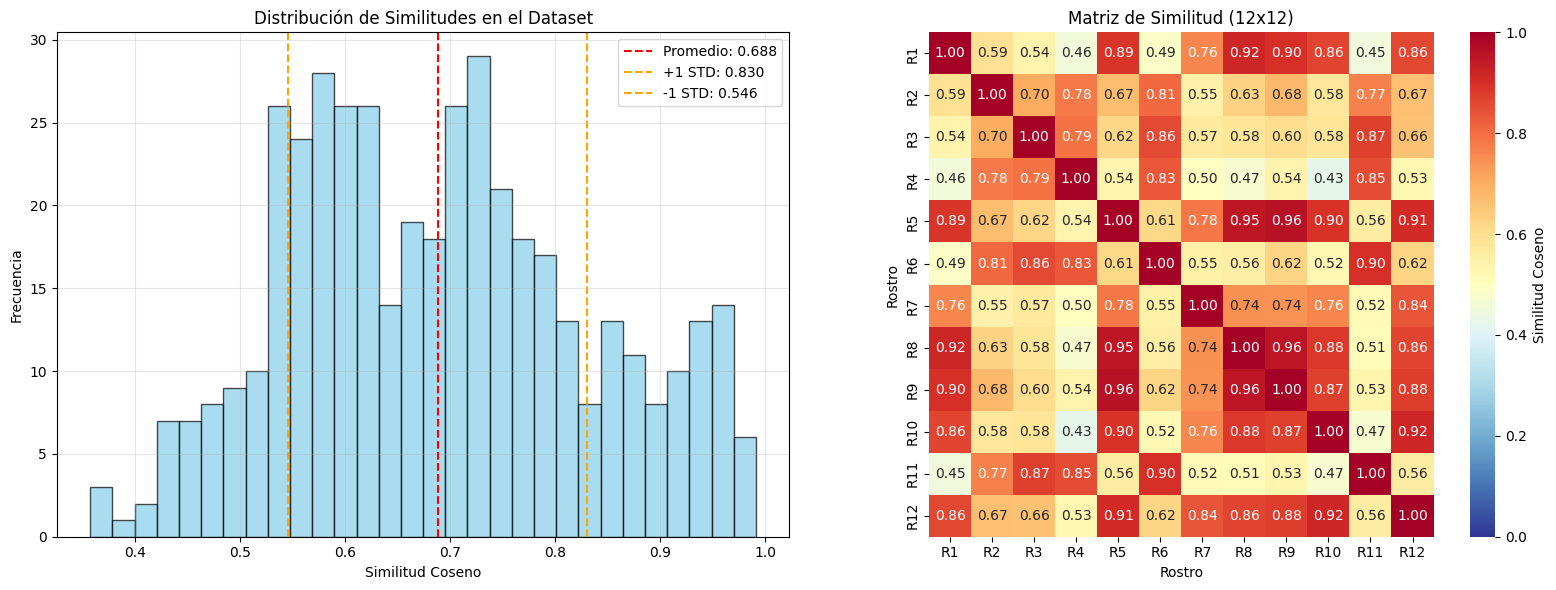

📊 Gráfico guardado en: /content/drive/MyDrive/Tesis_Entrenamiento_Facial_Vivo/results/similarity_analysis_20250706_154504.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

# =============================================================================
# PASO 4.4: ANÁLISIS DE SIMILITUD COSENO DEL DATASET
# =============================================================================

print(f"\n📊 ANÁLISIS DE SIMILITUD COSENO DEL DATASET...")

# Calcular matriz de similitud coseno
similarity_matrix = cosine_similarity(embeddings_array)

# Estadísticas de similitud
upper_triangle = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]
similitud_promedio = np.mean(upper_triangle)
similitud_std = np.std(upper_triangle)
similitud_min = np.min(upper_triangle)
similitud_max = np.max(upper_triangle)

print(f"📈 Estadísticas de similitud:")
print(f"   • Similitud promedio: {similitud_promedio:.4f}")
print(f"   • Desviación estándar: {similitud_std:.4f}")
print(f"   • Rango: [{similitud_min:.4f}, {similitud_max:.4f}]")
print(f"   • Número de comparaciones: {len(upper_triangle)}")

# Visualización de resultados
plt.figure(figsize=(16, 6))

# Subplot 1: Distribución de similitudes
plt.subplot(1, 2, 1)
plt.hist(upper_triangle, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(similitud_promedio, color='red', linestyle='--',
            label=f'Promedio: {similitud_promedio:.3f}')
plt.axvline(similitud_promedio + similitud_std, color='orange', linestyle='--',
            label=f'+1 STD: {similitud_promedio + similitud_std:.3f}')
plt.axvline(similitud_promedio - similitud_std, color='orange', linestyle='--',
            label=f'-1 STD: {similitud_promedio - similitud_std:.3f}')
plt.xlabel('Similitud Coseno')
plt.ylabel('Frecuencia')
plt.title('Distribución de Similitudes en el Dataset')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Matriz de similitud con números
plt.subplot(1, 2, 2)
# Mostrar matriz completa si es pequeña, sino muestra muestra
if len(embeddings_dataset) <= 12:
    sample_size = len(embeddings_dataset)
    sample_matrix = similarity_matrix
    sample_names = [f"R{i+1}" for i in range(sample_size)]
else:
    sample_size = 12
    sample_matrix = similarity_matrix[:sample_size, :sample_size]
    sample_names = [f"R{i+1}" for i in range(sample_size)]

# Crear heatmap con valores numéricos
sns.heatmap(sample_matrix,
            annot=True,  # Mostrar números
            fmt='.2f',   # Formato de 2 decimales
            cmap='RdYlBu_r',
            square=True,
            cbar_kws={'label': 'Similitud Coseno'},
            xticklabels=sample_names,
            yticklabels=sample_names,
            vmin=0, vmax=1)
plt.title(f'Matriz de Similitud ({sample_size}x{sample_size})')
plt.xlabel('Rostro')
plt.ylabel('Rostro')

plt.tight_layout()

# Guardar gráfico
plot_path = Path(DIRS['results']) / f"similarity_analysis_{timestamp}.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"📊 Gráfico guardado en: {plot_path}")